In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import binarize

In [2]:
df = pd.read_excel("Simmons.xls")

print(df.head())
print(df.shape)
print(df.columns)

   Customer  Spending  Card  Coupon
0         1     2.291     1       0
1         2     3.215     1       0
2         3     2.135     1       0
3         4     3.924     0       0
4         5     2.528     1       0
(100, 4)
Index(['Customer', 'Spending', 'Card', 'Coupon'], dtype='object')


In [3]:
print(df.describe())

         Customer    Spending        Card      Coupon
count  100.000000  100.000000  100.000000  100.000000
mean    50.500000    3.333790    0.500000    0.400000
std     29.011492    1.741298    0.502519    0.492366
min      1.000000    1.058000    0.000000    0.000000
25%     25.750000    2.059000    0.000000    0.000000
50%     50.500000    2.805500    0.500000    0.000000
75%     75.250000    4.468250    1.000000    1.000000
max    100.000000    7.076000    1.000000    1.000000


In [4]:
X = df[["Spending", "Card"]]
y = df["Coupon"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

print(X_train.shape)
print(X_test.shape)

(75, 2)
(25, 2)


In [6]:
model = LogisticRegression(solver='lbfgs')
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [7]:
y_predict = model.predict(X_test)
y_predict_train = model.predict(X_train)

y_prob = model.predict_proba(X_test)[:, 1]
y_prob_train = model.predict_proba(X_train)[:, 1]

In [8]:
acc = accuracy_score(y_test, y_predict)
print("Accuracy =", round(acc, 2))

Accuracy = 0.6


In [9]:
cm = confusion_matrix(y_test, y_predict)
print(cm)

tn, fp, fn, tp = cm.ravel()

[[12  1]
 [ 9  3]]


In [10]:
Accuracy = (tp + tn) / (tp + tn + fp + fn)
print("Accuracy {:.2f}".format(Accuracy))

Specificity = tn / (tn + fp)
print("Specificity {:.2f}".format(Specificity))

Sensitivity = tp / (tp + fn)
print("Sensitivity {:.2f}".format(Sensitivity))

Accuracy 0.60
Specificity 0.92
Sensitivity 0.25


In [11]:
log_ROC_AUC1 = roc_auc_score(y_train, y_predict_train)

fpr1, tpr1, thresholds1 = roc_curve(y_train, y_prob_train)
roc_auc1 = auc(fpr1, tpr1)

print("Area under AUC =", round(roc_auc1, 2))

Area under AUC = 0.66


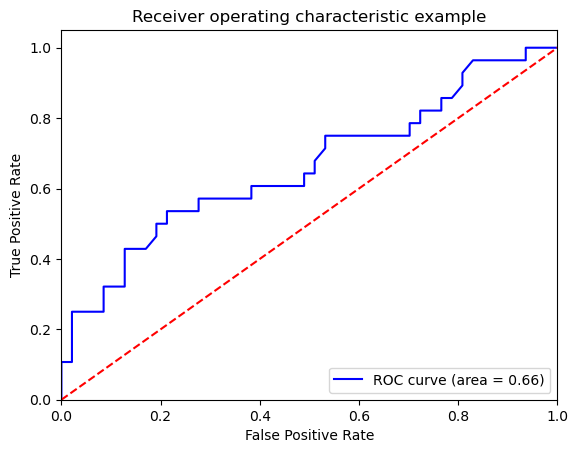

In [12]:
plt.figure()

plt.plot(
    fpr1,
    tpr1,
    color='blue',
    label='ROC curve (area = %0.2f)' % roc_auc1
)

plt.plot([0, 1], [0, 1], 'r--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('Receiver operating characteristic example')

plt.legend(loc="lower right")
plt.show()

In [13]:
log_ROC_AUC = roc_auc_score(y_test, y_predict)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print("Area under AUC =", round(roc_auc, 2))

Area under AUC = 0.78


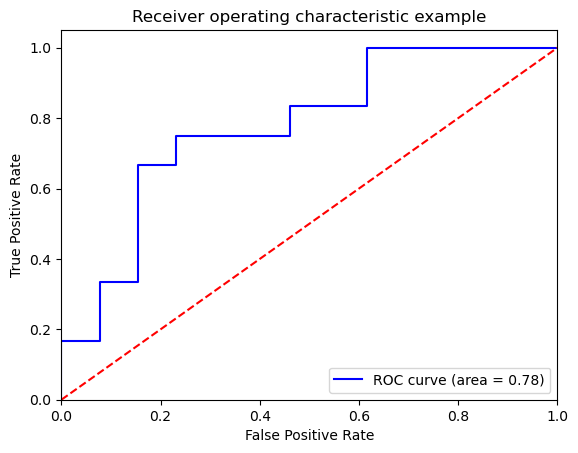

In [14]:
plt.figure()

plt.plot(
    fpr,
    tpr,
    color='blue',
    label='ROC curve (area = %0.2f)' % roc_auc
)

plt.plot([0, 1], [0, 1], 'r--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('Receiver operating characteristic example')

plt.legend(loc="lower right")
plt.show()